In [2]:
using Random, Revise
using CairoMakie
using LinearAlgebra
using StatsBase
using LaTeXStrings
using DifferentialEquations
using JLD2
includet("Utils.jl")
using .Utils
includet("FigureStyles.jl")
using .FigureStyles
set_theme!(SingleColumnTheme)

In [15]:
# Run qTTheory.jl
f = load("results/qTTheory.jld2")
Cx_theo = f["Cx"]
mx_theo = f["mx"]
Δx_theo = f["Δx"]
ratio_theo = f["ratio"]   

function _plateau(Kx)
    n = length(Kx)
    hw = min(n ÷ 32, 8)
    c = fld(n, 2) + 1
    clamp(mean(@view Kx[max(1, c - hw):min(n, c + hw)]), 0.0, max(Kx[1], 0.0))
end

nτc_theo, np_theo = size(Δx_theo)
qT_theo = fill(NaN, nτc_theo, np_theo)
for ic in 1:nτc_theo, jj in 1:np_theo
    Δ = Δx_theo[ic, jj]
    Δ > 0 || continue
    Kx = @view(Cx_theo[:, ic, jj]) .- mx_theo[ic, jj]^2
    qT_theo[ic, jj] = (Δ - _plateau(Kx)) / Δ
end

In [17]:
# Run ActivationConDivSearch.jl
f = load("./results/ActivationConDivSearch.jld2")
qmean_all = f["qmean"]
qstd_all = f["qstd"]
ratio = f["ratio"]
τc_vec = f["τc_vec"]
J0 = f["J0"]
g = f["g"]
N = f["N"]
num_repeats = f["num_repeats"]
activation_names = f["activation_names"]
activation_titles = Dict(
    "tanh" => L"\phi = \tanh",
    "nonnegative" => L"\phi = (1+\tanh)/2",
)
cmap = to_colormap(:navia10)
cmap = reverse(cgrad(:navia10, 12, categorical=true))
Colors = cmap[[4,7,10]]
figq = Figure(size=(3.35*72, 4.0*72), figure_padding=(1f0, 9f0, 2f0, 2f0))
for (aa, activation_name) in enumerate(activation_names)
    qmean = qmean_all[aa, :, :]
    qstd = qstd_all[aa, :, :]
    ax = Axis(figq[1, aa], xlabel=L"\tau^\mathrm{div}/\tau^\mathrm{con}",
        ylabel=aa == 1 ? L"q_T" : "", xscale=log10,
        xticks=[1e-1, 1, 1e1],
        title=activation_titles[activation_name], titlesize=8)
    if aa == 1
        for i in 1:3
            lines!(ax, ratio[1, :], ones(length(ratio[1,:])); label=L"%$(N*τc_vec[i])", linewidth=1.75, color=Colors[i], alpha=0.8)
        end
    end

    if aa == 2
        for i in 1:3
            lines!(ax, ratio_theo[i, :], qT_theo[i, :]; color=Colors[i], linewidth=1.75, alpha=0.8)
        end
    end
    for i in 1:3
        errorbars!(ax, ratio[i, :], qmean[i, :], qstd[i, :]; color=Colors[i], alpha=0.8, linewidth=1.0)
        scatter!(ax, ratio[i, :], qmean[i, :]; color=Colors[i], markersize=5 , alpha=1.0)
    end
    if aa == 1
        ax.limits = (0.65e-1, 1.35e1, 0.0, 1.2)
    else
        ax.limits = (0.65e-1, 1.35e1, -0.005, 0.07)
        ax.yticks = [0.0, 0.03, 0.06]
    end
    aa == 1 && axislegend(ax, L"Nτ^{\text{chn}}"; titlesize=8, patchsize=(10, 6), position=(0.05, 1.0), nbanks=2, rowgap=2, colgap=4)
end
Label(figq[1, 1, TopLeft()], "(a)"; fontsize=12, padding=(0f0, 5f0, 7f0, 0f0))
Label(figq[1, 2, TopLeft()], "(b)"; fontsize=12, padding=(0f0, 5f0, 7f0, 0f0))
rowsize!(figq.layout, 1, Relative(1/3))

### Visualize more trajectories for different $\tau^{\mathrm{div}}/\tau^{\mathrm{con}}$

In [18]:
N = 2000
J0 = -5 / N
g = 5.0
Random.seed!(12335)
x0 = randn(N) * 0.5
τc = 0.25/N

# values of τconv to explore
τconv_vals = [0.125, 0.25, 0.5] ./ N
tspan = (0.0, 300.0)
sims = []

for τconv in τconv_vals
    τdiv = τc^2 / τconv
    J = CreateJ(N, J0, g, (τc, 0.0, τconv, τdiv))
    prob = ODEProblem(GaussianPositiveActivation!, x0, tspan, J)
    sol = solve(prob, Tsit5(), saveat=0.2)
    X = Array(sol)'
    push!(sims, (sol, X, τconv, τdiv))
end

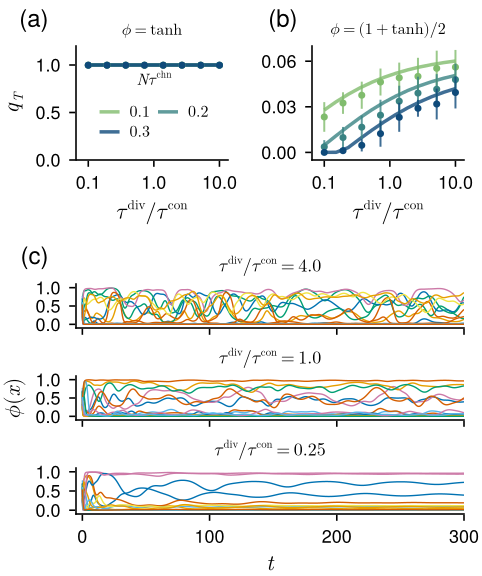

In [ ]:
TrajectoryGrids = figq[2, 1:2] = GridLayout()
for (j, (sol, X, τconv, τdiv)) in enumerate(sims)
    ratio = τdiv / τconv
    ax = Axis(TrajectoryGrids[j, 1],
        title=L"\tau^{\mathrm{div}}/\tau^{\mathrm{con}} = %$(round(ratio, digits=3))",
        limits=(-5, 300, -0.1, 1.1), titlesize=9)
    if j == 3
        ax.xlabel = L"t"
    else
        ax.xticklabelsvisible = false
    end
    if j == 2
        ax.ylabel = L"\phi(x)"
    end
    for i in 1:20
        lines!(ax, sol.t, ϕ_positive.(X[:, i]); linewidth=0.7)
    end
end
Label(TrajectoryGrids[1, 1, TopLeft()], "(c)"; fontsize=12, padding=(0f0, 5f0, 7f0, 0f0))
filename = "ConVSDiv$(replace(string(N*J0), "."=>"p"))" *
           "Ntauc$(replace(string(N*τc), "."=>"p"))" *
           "g$(replace(string(g), "."=>"p")).pdf"
rowgap!(TrajectoryGrids, 6)
rowgap!(figq.layout, 9)
display(figq)
# save("./images/"*filename, figq, pt_per_unit=1);